Question 04

Otsu's threshold value: 101.0


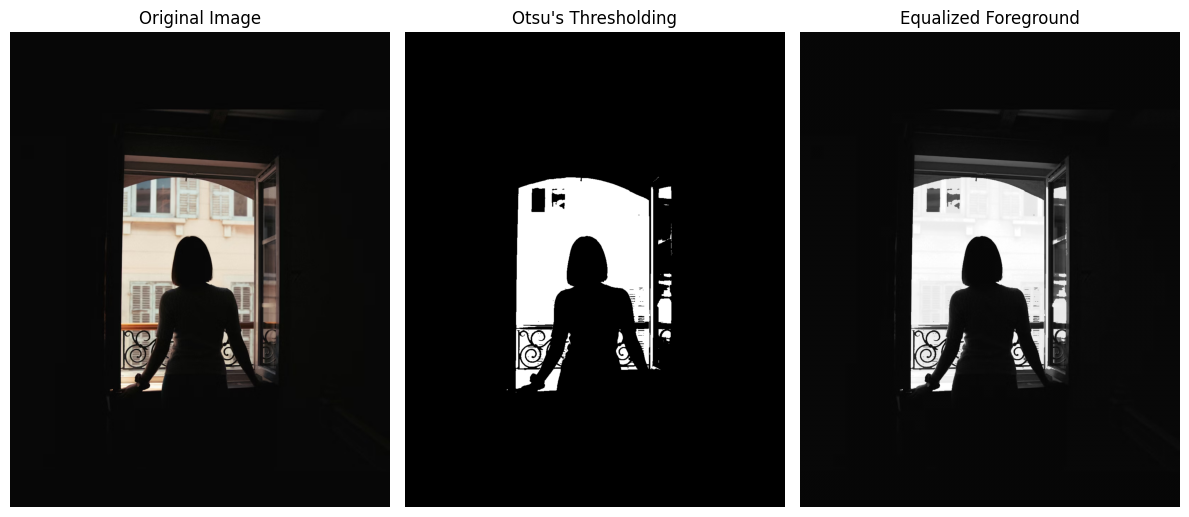

In [8]:
#Question 04

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

f = cv.imread('image.png')
assert f is not None, "Image not found. Please check the path."

#convert to grayscale
gray = cv.cvtColor(f, cv.COLOR_BGR2GRAY)

#Question 4 (a) Otsu's thresholding
ret, otsu_thresh = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

print(f"Otsu's threshold value: {ret}")

#create a foreground mask
mask = otsu_thresh.astype(bool)

#extract the foreground
foreground = cv.bitwise_and(gray, gray, mask=mask.astype(np.uint8))


#Question 4 (b) Histogram equalization only foreground
equalized = cv.equalizeHist(gray)
equalized_foreground = gray.copy()
equalized_foreground[mask] = equalized[mask]

#Display the results
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(cv.cvtColor(f, cv.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Otsu's Thresholding")
plt.imshow(otsu_thresh, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Equalized Foreground')
plt.imshow(equalized_foreground, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

